In [2]:
# ── Bootstrap: add src/ to path so path_config is importable ─────────────
import sys, os

# Jupyter sets cwd to the notebook folder (notebooks/).  src/ is one level up.
_here = os.getcwd()                                   # .../notebooks/
_root_candidate = os.path.dirname(_here)              # .../project_root/
for _candidate in [os.path.join(_here, 'src'),
                   os.path.join(_root_candidate, 'src')]:
    if os.path.isdir(_candidate) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

# ── path_config handles everything from here ──────────────────────────────
from path_config import PROJECT_ROOT, SRC_PATH, DATA_DIR, make_output_dir, data_path, print_paths
print_paths()

OUTPUT_DIR = make_output_dir('project2')
print(f'📁 Outputs      : {OUTPUT_DIR}')

# ── Standard imports ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Shared project modules ────────────────────────────────────────────────
from data_loader      import load_data, print_data_summary
from data_cleaner     import clean_pipeline
from visualization    import (
    plot_score_distributions,
    plot_gender_comparison,
    plot_test_prep_impact,
    plot_parental_education_effect,
    plot_lunch_effect,
    plot_ethnicity_heatmap,
    plot_correlation_matrix,
    plot_grade_distribution,
    plot_multi_factor_scatter,
    plot_executive_dashboard,
)
from statistical_analysis import (
    descriptive_stats,
    normality_tests,
    t_test_two_groups,
    anova_test,
    correlation_analysis,
    pass_rate_by_group,
    full_stats_report,
)
from report_generator import generate_markdown_report, generate_json_report

print('✅ All imports successful.')


📁 Project root : /Users/tejaspatil/Documents/Data Analysis Portfolio
📁 src/         : /Users/tejaspatil/Documents/Data Analysis Portfolio/src  (on sys.path)
📁 data/        : /Users/tejaspatil/Documents/Data Analysis Portfolio/data
📁 Outputs      : /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2
✅ All imports successful.


In [ ]:

DATA_PATH = data_path('StudentsPerformance.csv')
print(f'Loading: {DATA_PATH}')
df_raw = load_data(DATA_PATH)
df_raw.head()


Loading: /Users/tejaspatil/Documents/Data Analysis Portfolio/data/StudentsPerformance.csv
✅ Data loaded successfully: 1000 rows × 8 columns


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# Pretty-printed dataset summary
print_data_summary(df_raw)



📊 DATASET SUMMARY
  Rows    : 1000
  Columns : 8

📌 Missing Values:
  ✅ gender: 0 (0.0%)
  ✅ race/ethnicity: 0 (0.0%)
  ✅ parental level of education: 0 (0.0%)
  ✅ lunch: 0 (0.0%)
  ✅ test preparation course: 0 (0.0%)
  ✅ math score: 0 (0.0%)
  ✅ reading score: 0 (0.0%)
  ✅ writing score: 0 (0.0%)

📌 Score Statistics:
  math score      → mean=66.1, std=15.2, min=0, max=100
  reading score   → mean=69.2, std=14.6, min=17, max=100
  writing score   → mean=68.1, std=15.2, min=10, max=100


In [5]:
print(f"Shape : {df_raw.shape}")
print(f"\nData types:\n{df_raw.dtypes}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")


Shape : (1000, 8)

Data types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [6]:
df = clean_pipeline(df_raw)

# Preview engineered features
df[["math score","reading score","writing score",
    "average_score","total_score","score_std","passed_all","grade"]].head(10)



🔧 Running cleaning pipeline …
✅ No duplicate rows found.
✅ No missing numeric values.
✅ No missing categorical values.
✅ Pipeline complete. Final shape: (1000, 14)



,math score,reading score,writing score,average_score,total_score,score_std,passed_all,grade
0,72,72,74,72.67,218,1.15,True,C
1,69,90,88,82.33,247,11.59,True,B
2,90,95,93,92.67,278,2.52,True,A
3,47,57,44,49.33,148,6.81,False,F
4,76,78,75,76.33,229,1.53,True,C
5,71,83,78,77.33,232,6.03,True,C
6,88,95,92,91.67,275,3.51,True,A
7,40,43,39,40.67,122,2.08,False,F
8,64,64,67,65.00,195,1.73,True,D
9,38,60,50,49.33,148,11.02,False,F


In [7]:
print("Grade distribution:")
print(df["grade"].value_counts().sort_index())
print(f"\nPass rate (all subjects ≥ 60): {df['passed_all'].mean()*100:.1f}%")


Grade distribution:
grade
F    274
D    252
C    260
B    156
A     58
Name: count, dtype: int64

Pass rate (all subjects ≥ 60): 60.3%


In [8]:
desc = descriptive_stats(df)
desc.style.background_gradient(cmap="Blues", subset=["mean","std"]).format("{:.2f}")


,mean,median,std,skewness,kurtosis,min,max,iqr
column,,,,,,,,
math score,66.09,66.00,15.16,-0.28,0.28,0.00,100.00,20.00
reading score,69.17,70.00,14.60,-0.26,-0.07,17.00,100.00,20.00
writing score,68.05,69.00,15.20,-0.29,-0.03,10.00,100.00,21.25
average_score,67.77,68.33,14.26,-0.30,0.13,9.00,100.00,19.34


In [9]:
norm = normality_tests(df)
norm.style.applymap(
    lambda v: "background-color: #d4edda" if v is True else
              ("background-color: #f8d7da" if v is False else ""),
    subset=["is_normal"]
)


,W_stat,p_value,is_normal
column,,,
math score,0.993200,0.000100,False
reading score,0.992900,0.000100,False
writing score,0.992000,0.000000,False
average_score,0.993200,0.000100,False


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q1_score_distributions.png


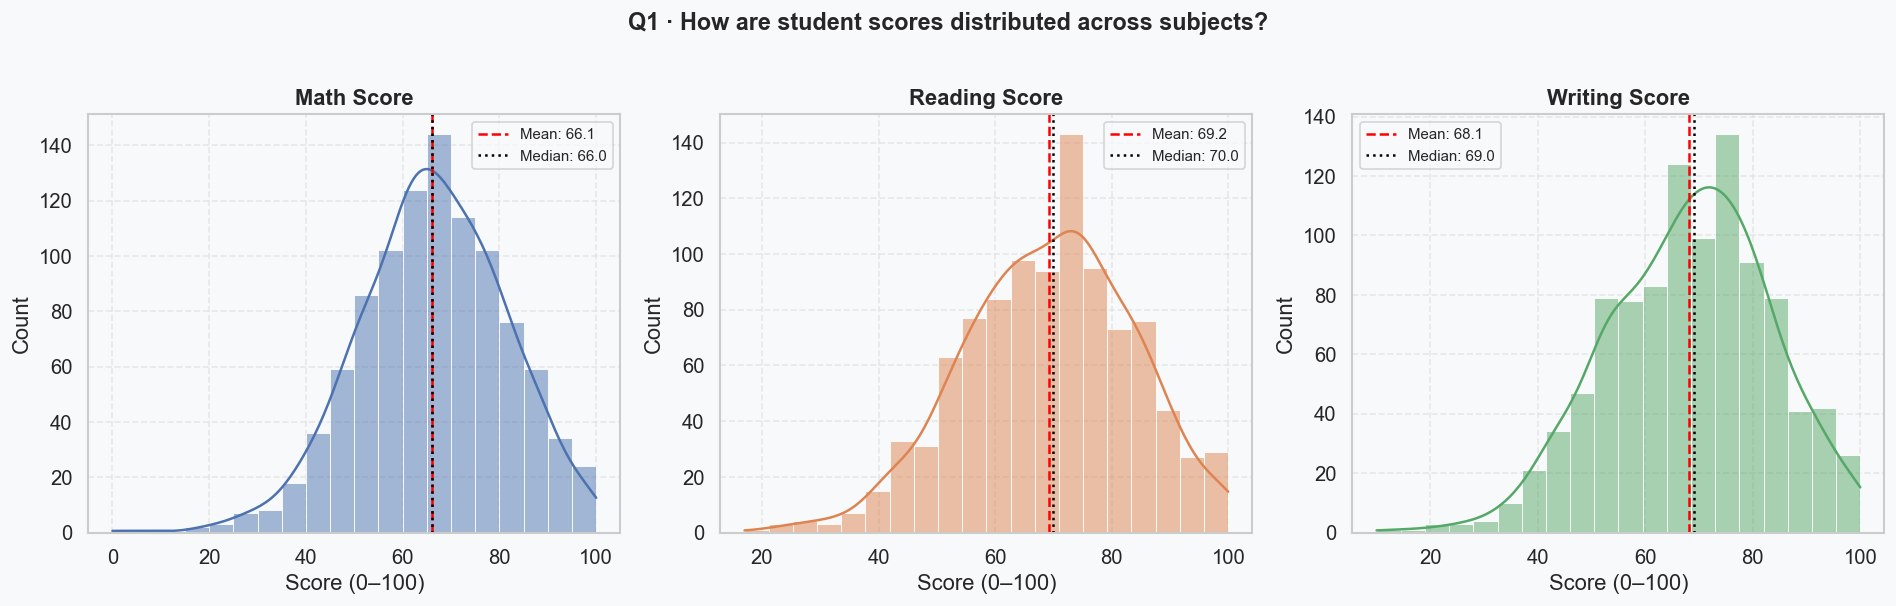

In [10]:
fig = plot_score_distributions(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q1_score_distributions.png"))
plt.show()


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q2_gender_comparison.png


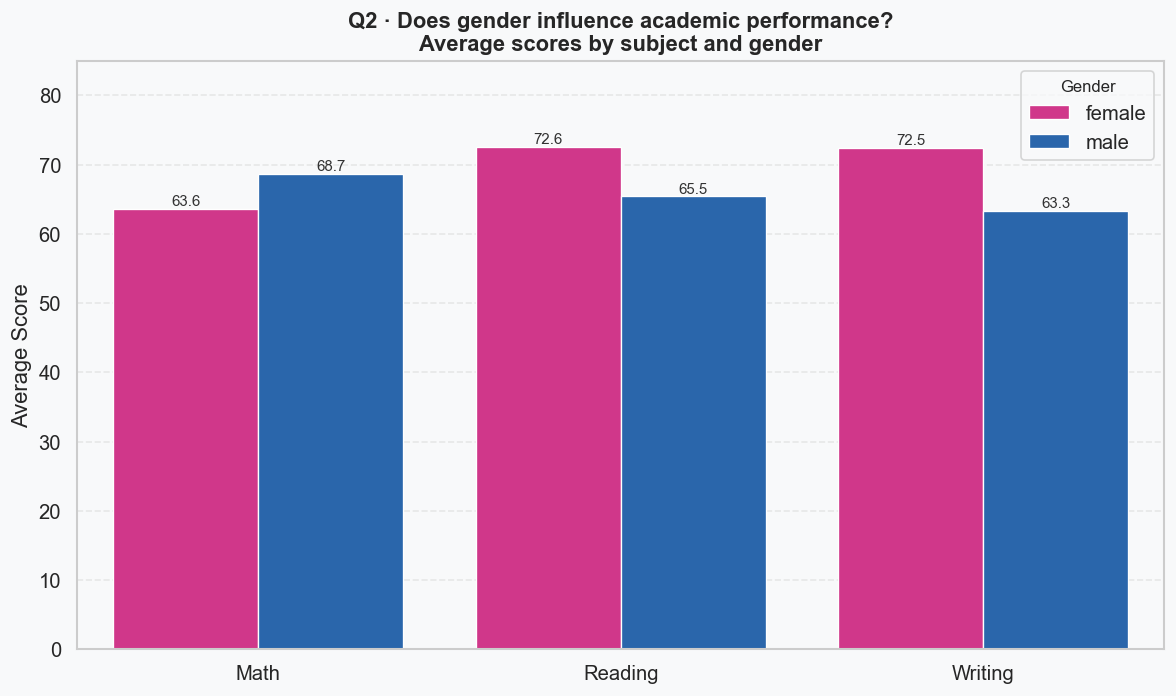


T-test: p = 0.0 | Significant: True
Effect size (Cohen's d): 0.2642 (small)


In [11]:
fig = plot_gender_comparison(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q2_gender_comparison.png"))
plt.show()

result = t_test_two_groups(df, "gender", "average_score")
print(f"\nT-test: p = {result['p_value']} | Significant: {result['significant']}")
print(f"Effect size (Cohen's d): {result['cohen_d']} ({result['effect_size']})")


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q3_test_prep.png


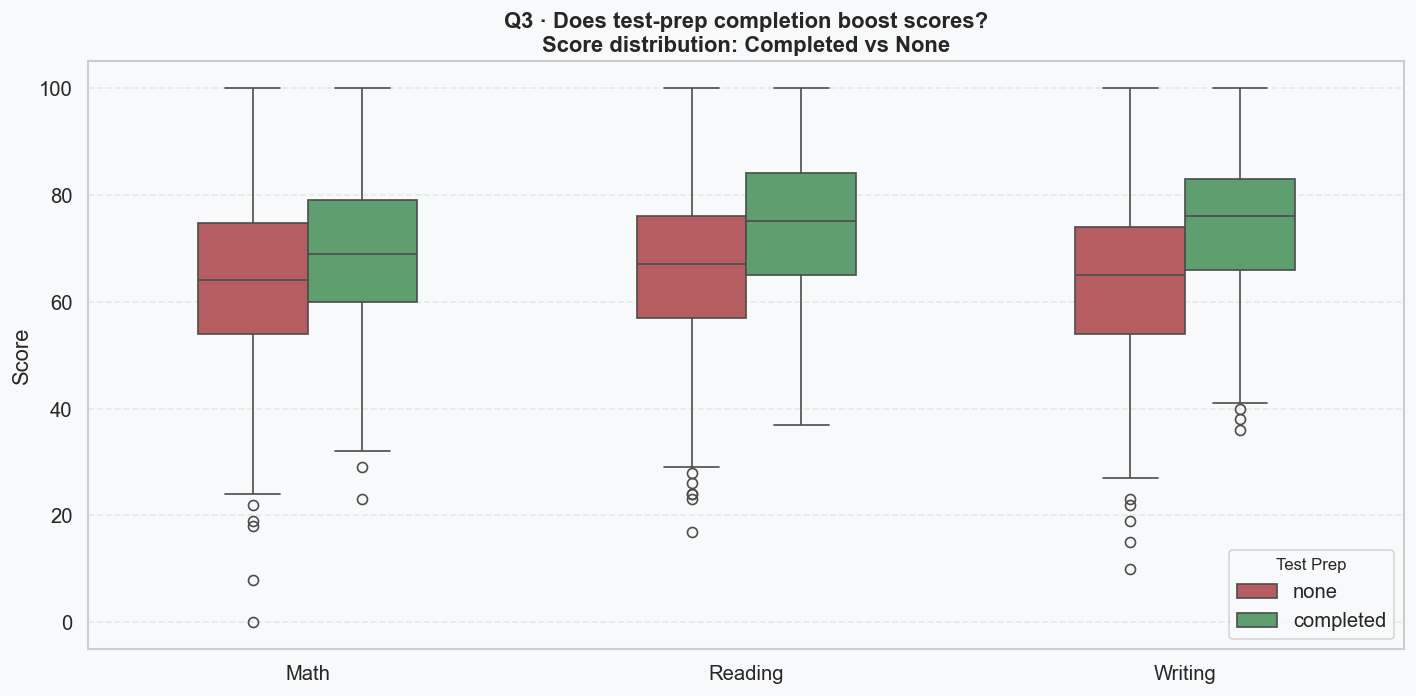


T-test: p = 0.0 | Significant: True
Score uplift: 7.6 points


In [12]:
fig = plot_test_prep_impact(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q3_test_prep.png"))
plt.show()

result = t_test_two_groups(df, "test preparation course", "average_score")
print(f"\nT-test: p = {result['p_value']} | Significant: {result['significant']}")
vals = list(result["groups"].values())
print(f"Score uplift: {abs(vals[0]-vals[1]):.1f} points")


### Q4 · How does parental education level relate to student performance?
**Business insight:** A strong parental education gradient may justify family-engagement
or mentorship programmes targeting first-generation students.


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q4_parental_education.png


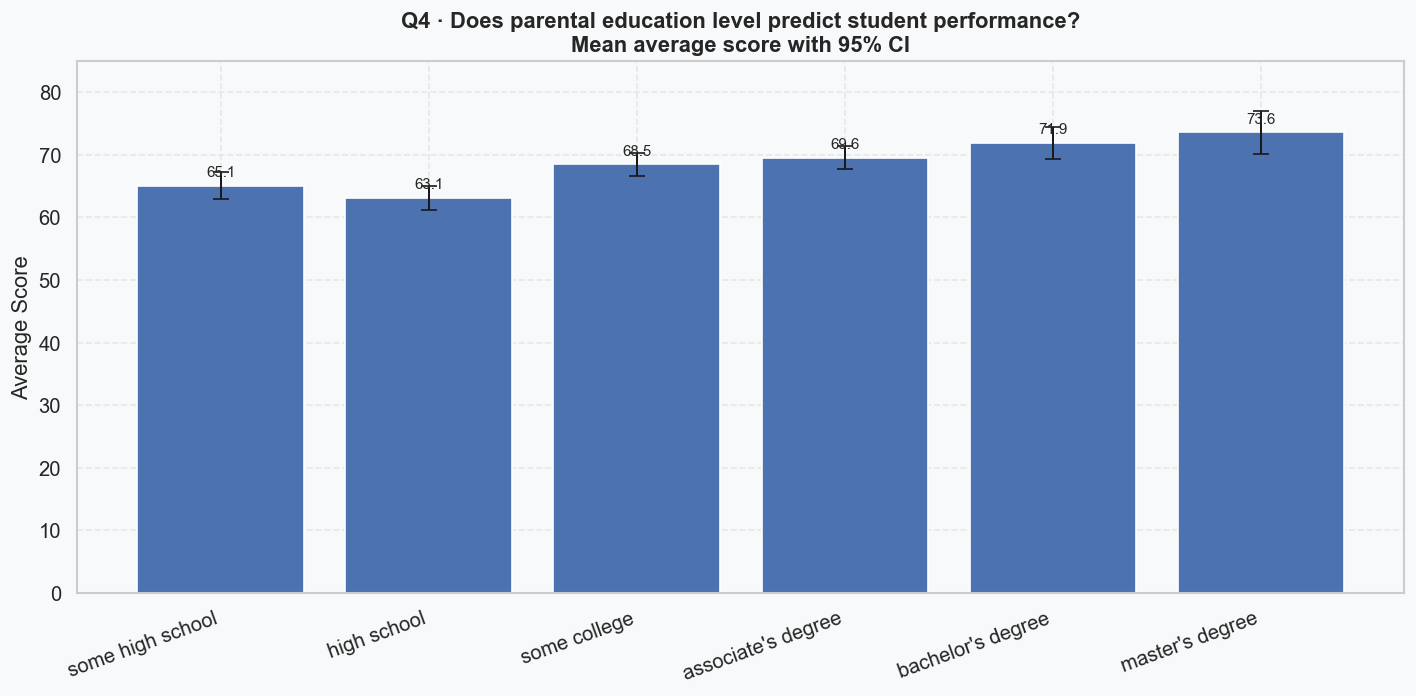


ANOVA: F = 10.7529, p = 0.0
Significant: True

Group means (sorted):
  high school                   : 63.10
  some high school              : 65.11
  some college                  : 68.48
  associate's degree            : 69.57
  bachelor's degree             : 71.92
  master's degree               : 73.60


In [13]:
fig = plot_parental_education_effect(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q4_parental_education.png"))
plt.show()

edu_anova = anova_test(df, "parental level of education", "average_score")
print(f"\nANOVA: F = {edu_anova['f_stat']}, p = {edu_anova['p_value']}")
print(f"Significant: {edu_anova['significant']}")
print("\nGroup means (sorted):")
for grp, mean in sorted(edu_anova["group_means"].items(), key=lambda x: x[1]):
    print(f"  {grp:30s}: {mean:.2f}")


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q5_lunch_effect.png


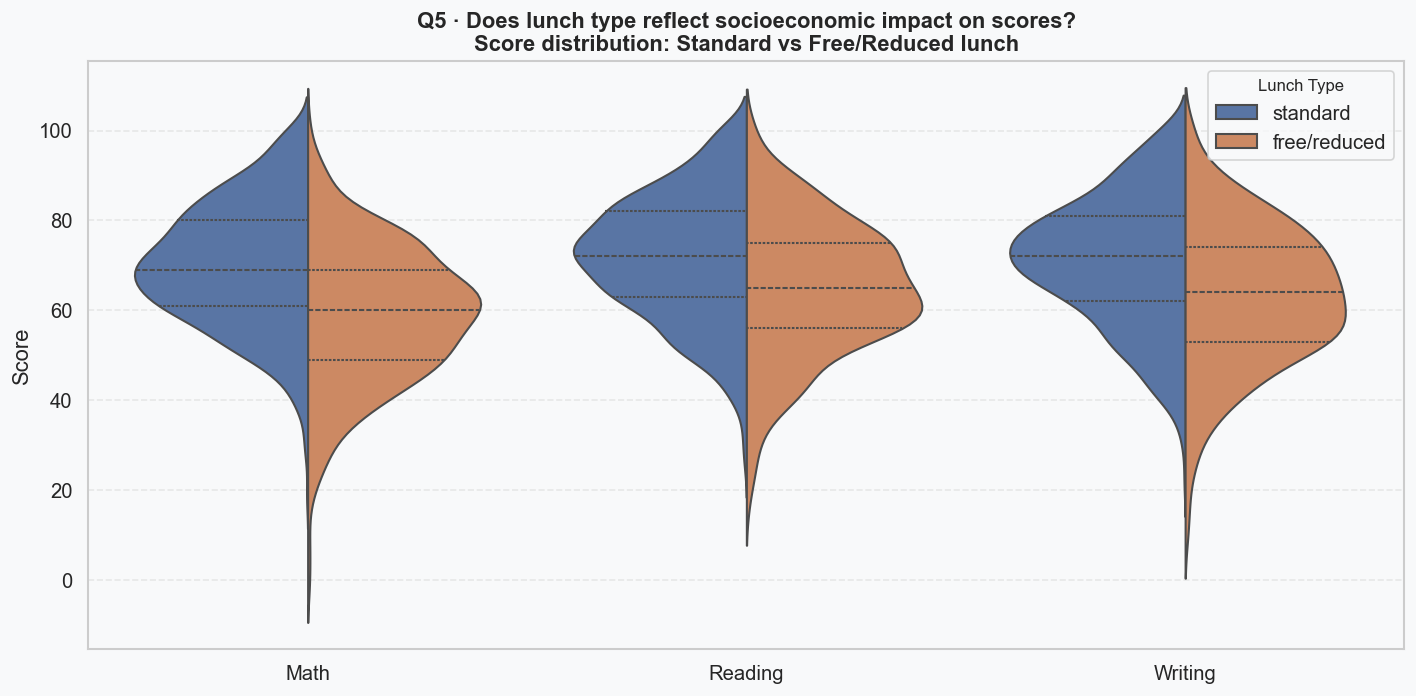


T-test: p = 0.0 | Significant: True
Effect size: 0.6243 (medium)


In [14]:
fig = plot_lunch_effect(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q5_lunch_effect.png"))
plt.show()

result = t_test_two_groups(df, "lunch", "average_score")
print(f"\nT-test: p = {result['p_value']} | Significant: {result['significant']}")
print(f"Effect size: {result['cohen_d']} ({result['effect_size']})")


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q6_ethnicity_heatmap.png


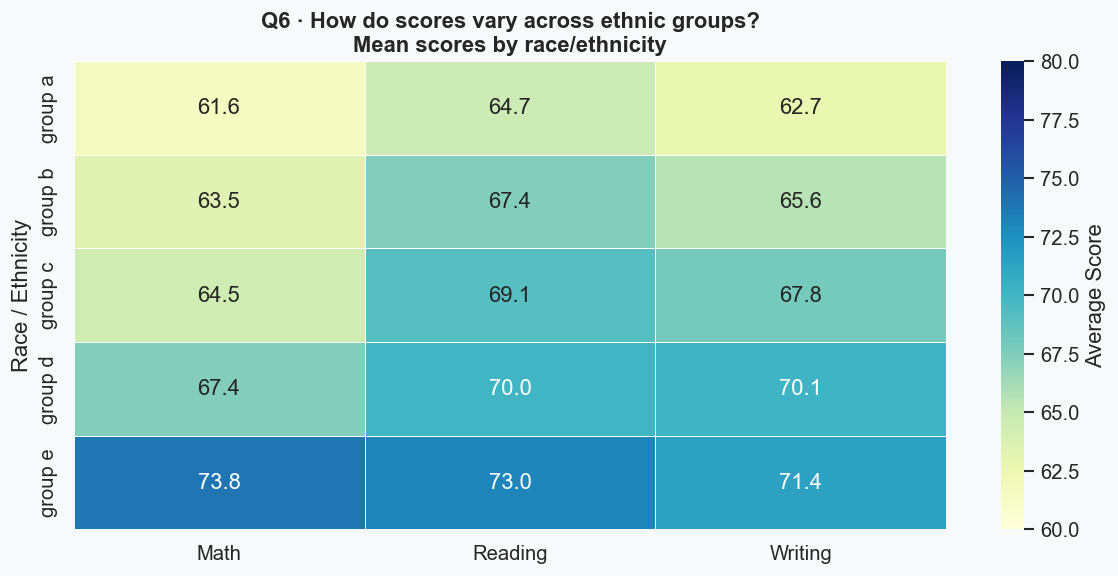


ANOVA: F = 9.0957, p = 0.0
  group e: 72.75
  group d: 69.18
  group c: 67.13
  group b: 65.47
  group a: 62.99


In [15]:
fig = plot_ethnicity_heatmap(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q6_ethnicity_heatmap.png"))
plt.show()

eth_anova = anova_test(df, "race/ethnicity", "average_score")
print(f"\nANOVA: F = {eth_anova['f_stat']}, p = {eth_anova['p_value']}")
for grp, mean in sorted(eth_anova["group_means"].items(), key=lambda x: x[1], reverse=True):
    print(f"  {grp}: {mean:.2f}")


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q7_correlation.png


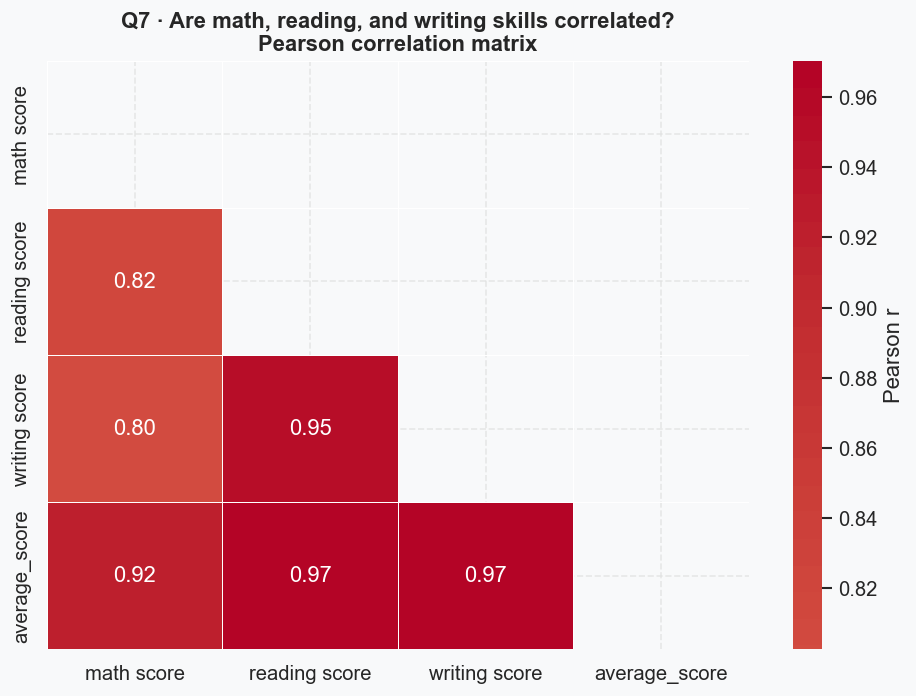


Pearson correlation matrix:
               math score  reading score  writing score  average_score
math score          1.000          0.818          0.803          0.919
reading score       0.818          1.000          0.955          0.970
writing score       0.803          0.955          1.000          0.966
average_score       0.919          0.970          0.966          1.000


In [16]:
fig = plot_correlation_matrix(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q7_correlation.png"))
plt.show()

corr = correlation_analysis(df)
print("\nPearson correlation matrix:")
print(corr)


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q8_grade_distribution.png


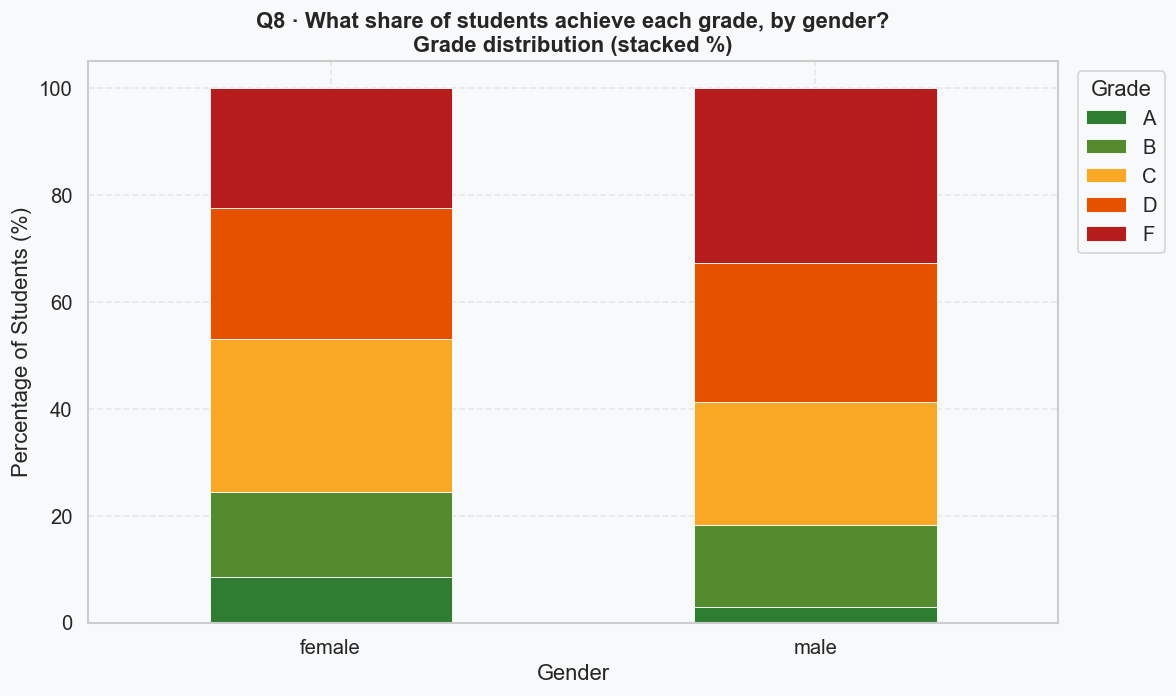


Grade distribution (%):
grade      F     D     C     B    A
gender                             
female  22.4  24.5  28.8  15.8  8.5
male    32.8  25.9  23.0  15.4  2.9


In [17]:
fig = plot_grade_distribution(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q8_grade_distribution.png"))
plt.show()

grade_pct = df.groupby(["gender","grade"]).size().unstack(fill_value=0)
grade_pct = grade_pct.div(grade_pct.sum(axis=1), axis=0) * 100
print("\nGrade distribution (%):")
print(grade_pct.round(1))


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/q9_multifactor_scatter.png


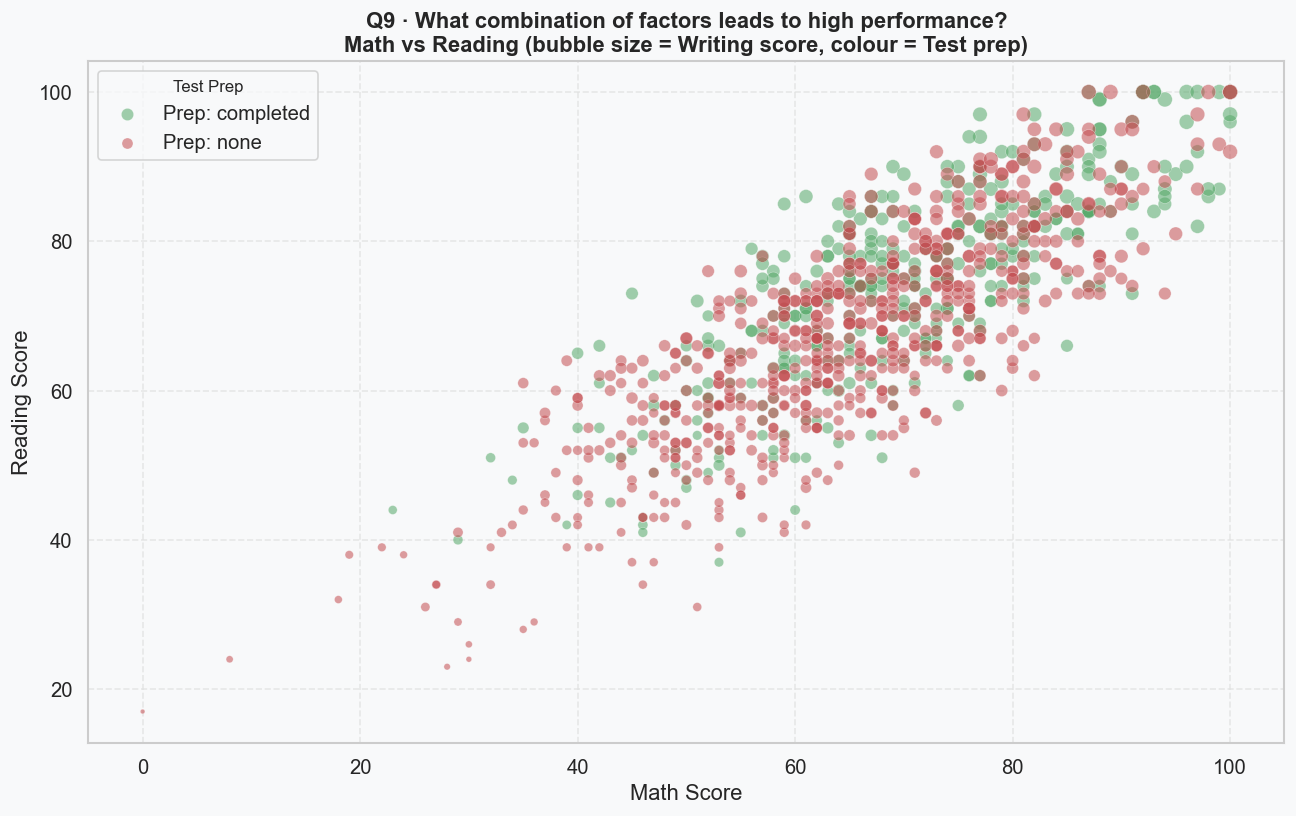

In [18]:
fig = plot_multi_factor_scatter(df, save_path=os.path.join(OUTPUT_DIR, "figures", "q9_multifactor_scatter.png"))
plt.show()


### Executive Dashboard
**Audience:** School leadership / non-technical stakeholders  
A single-page summary of the four most impactful KPIs.


  💾 Saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/figures/dashboard.png


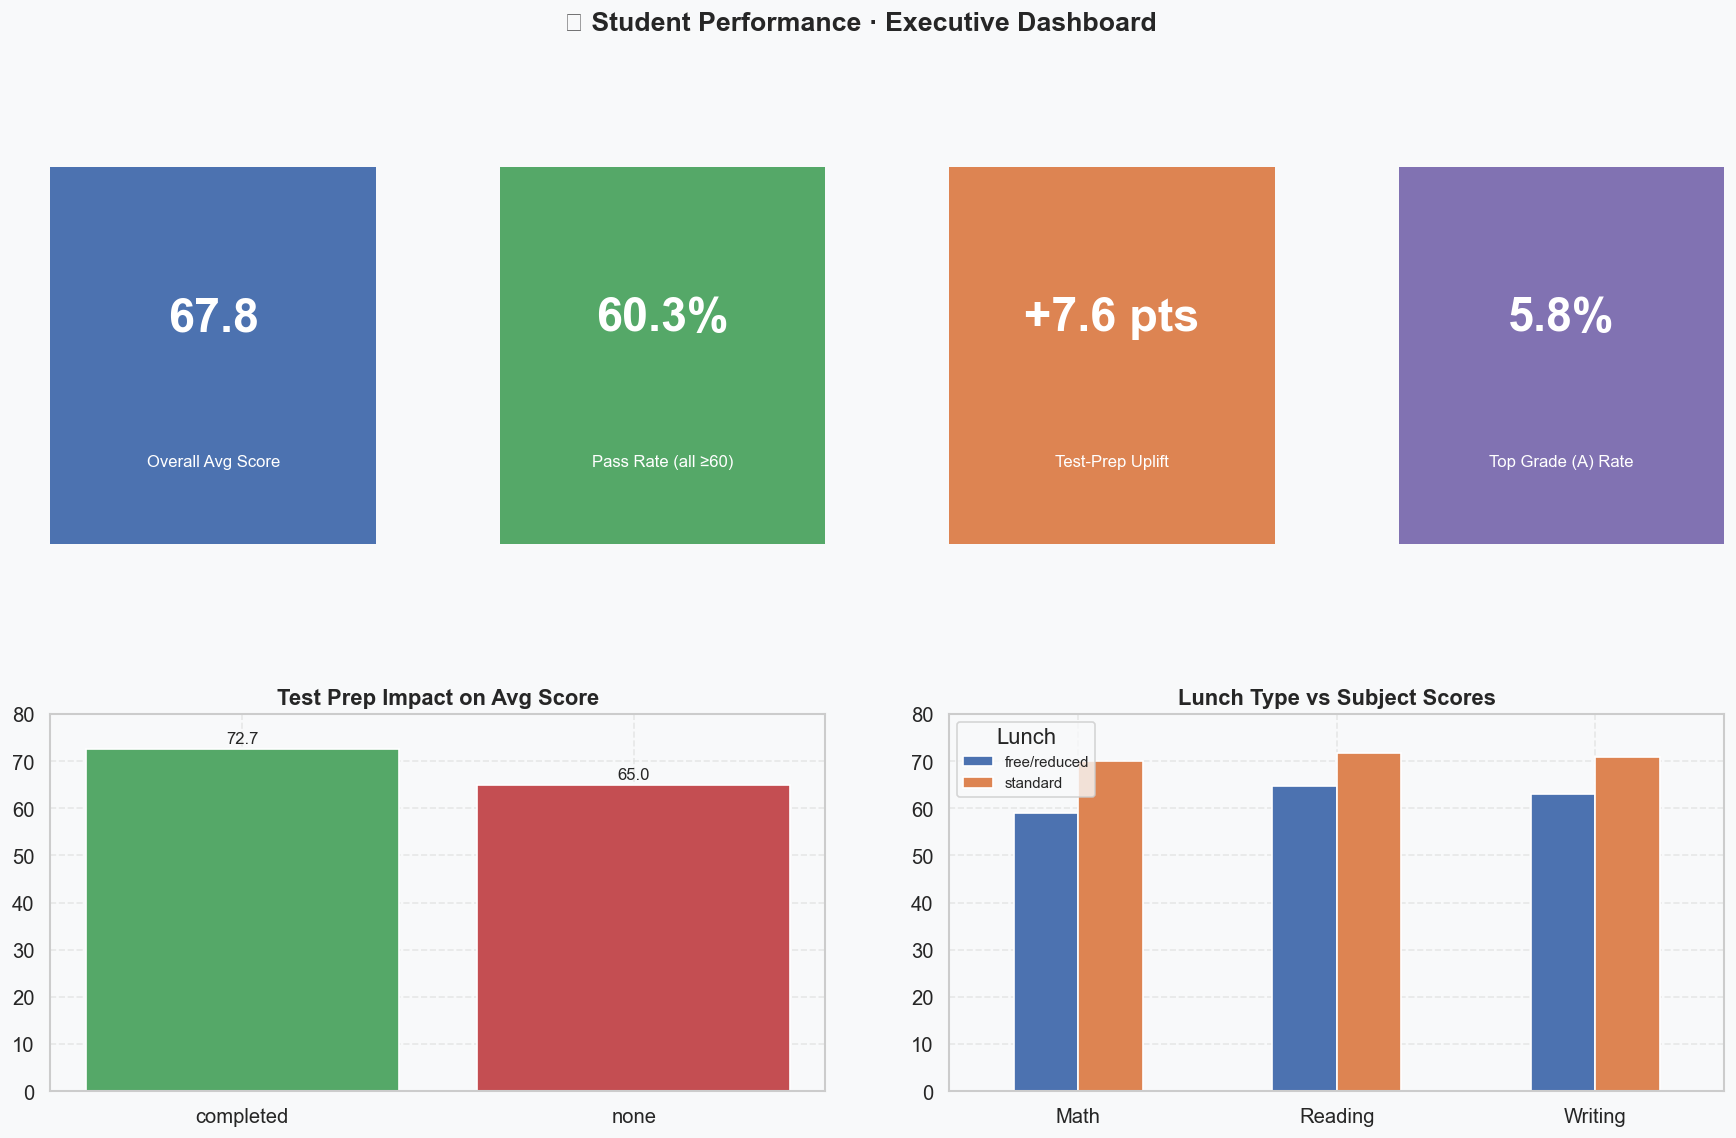

In [19]:
fig = plot_executive_dashboard(df, save_path=os.path.join(OUTPUT_DIR, "figures", "dashboard.png"))
plt.show()


In [20]:
for group_col in ["gender", "test preparation course", "lunch", "race/ethnicity"]:
    print(f"\n── Pass rate by {group_col} ──")
    print(pass_rate_by_group(df, group_col).to_string(index=False))



── Pass rate by gender ──
gender  pass_rate_%
female        76.06
  male        66.60

── Pass rate by test preparation course ──
test preparation course  pass_rate_%
              completed        83.24
                   none        64.95

── Pass rate by lunch ──
       lunch  pass_rate_%
    standard        79.84
free/reduced        56.34

── Pass rate by race/ethnicity ──
race/ethnicity  pass_rate_%
       group e        82.86
       group d        75.19
       group c        69.59
       group b        68.95
       group a        55.06


## 6 · Generate Full Statistical Report

In [21]:
stats = full_stats_report(df)

md_report = generate_markdown_report(
    stats,
    df_shape=df.shape,
    output_path=os.path.join(OUTPUT_DIR, "reports", "student_analysis_report.md"),
)

generate_json_report(
    stats,
    df_shape=df.shape,
    output_path=os.path.join(OUTPUT_DIR, "reports", "stats_report.json"),
)

# Preview first 60 lines
for line in md_report.split("\n")[:60]:
    print(line)


📐 Descriptive statistics …
📐 Normality tests …
📐 Gender vs average score (t-test) …
📐 Test-prep vs average score (t-test) …
📐 Lunch vs average score (t-test) …
📐 Parental education vs average score (ANOVA) …
📐 Ethnic group vs average score (ANOVA) …
📐 Correlation matrix …
📐 Pass rates by gender …
📐 Pass rates by test prep …
✅ Statistical analysis complete.

📄 Markdown report saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/reports/student_analysis_report.md
📄 JSON report saved → /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project2/reports/stats_report.json
# 🎓 Student Performance Analysis Report

_Generated: 2026-03-06 23:58_



## Executive Summary

This report analyses academic performance data for **1000 students** across 14 variables including gender, parental education, test preparation, and lunch type.

- Overall average score: **67.8 / 100**
- Highest pass-rate group (by gender): **0** at 76.1%
- Test-preparation completion is associat